# Regional Job Advertisement Trends

Explore quarterly regional indices using the cleaned MBIE Jobs Online dataset.

Index values measure change relative to each region's baseline, not the number of vacancies.

In [1]:
from pathlib import Path

import pandas as pd

data_file = Path("../data/processed/regional_quarterly.csv")

regional = pd.read_csv(data_file, parse_dates=["Date"])

regional.head()

,Date,Auckland,Bay of Plenty,Canterbury,Gisborne Hawke's Bay,Marlborough/NelsonTasman/West Coast,Manawatu/Wanganui-Taranaki,Northland,Otago Southland,Waikato,Wellington
0,2010-12-01,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1,2011-03-01,117.4,122.6,109.5,106.3,106.5,105.2,108.5,109.4,114.6,122.7
2,2011-06-01,123.8,115.0,139.8,101.8,100.0,106.0,109.6,108.3,119.4,122.2
3,2011-09-01,128.2,124.7,158.5,105.2,113.2,113.4,121.2,123.9,128.1,124.6
4,2011-12-01,101.0,106.0,140.5,104.3,114.8,101.7,109.1,120.0,105.8,103.1


In [2]:
regional.info()

<class 'pandas.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Date                                 63 non-null     datetime64[us]
 1   Auckland                             63 non-null     float64       
 2   Bay of Plenty                        63 non-null     float64       
 3   Canterbury                           63 non-null     float64       
 4   Gisborne Hawke's Bay                 63 non-null     float64       
 5   Marlborough/NelsonTasman/West Coast  63 non-null     float64       
 6   Manawatu/Wanganui-Taranaki           63 non-null     float64       
 7   Northland                            63 non-null     float64       
 8   Otago Southland                      63 non-null     float64       
 9   Waikato                              63 non-null     float64       
 10  Wellington                 

In [3]:
auckland = regional[["Date", "Auckland"]].copy()

In [4]:
auckland.head()

,Date,Auckland
0,2010-12-01,100.0
1,2011-03-01,117.4
2,2011-06-01,123.8
3,2011-09-01,128.2
4,2011-12-01,101.0


In [5]:
auckland["yoy_change_pct"] = (
    auckland["Auckland"].pct_change(periods=4, fill_method=None) * 100
)

auckland.tail(8)

,Date,Auckland,yoy_change_pct
55,2024-09-01,117.5,-31.923523
56,2024-12-01,93.7,-29.917726
57,2025-03-01,110.6,-25.270270
58,2025-06-01,104.8,-14.098361
59,2025-09-01,113.3,-3.574468
60,2025-12-01,93.2,-0.533618
61,2026-03-01,115.7,4.611212
62,2026-06-01,106.8,1.908397


In [6]:
regional_indices = regional.set_index("Date")

regional_yoy = regional_indices.pct_change(
    periods=4,
    fill_method=None
) * 100

In [7]:
regional_yoy.tail()

,Auckland,Bay of Plenty,Canterbury,Gisborne Hawke's Bay,Marlborough/NelsonTasman/West Coast,Manawatu/Wanganui-Taranaki,Northland,Otago Southland,Waikato,Wellington
Date,,,,,,,,,,
2025-06-01,-14.098361,-7.110439,-3.533569,-25.621415,-2.866699,-8.252853,2.108309,1.139694,-5.829384,-4.631380
2025-09-01,-3.574468,3.870254,11.788155,-3.166421,6.128748,-2.676182,-6.735553,15.781299,3.847981,8.891013
2025-12-01,-0.533618,6.963668,11.022044,-0.570033,9.452736,6.930693,0.168634,13.847709,9.564719,8.967083
2026-03-01,4.611212,15.664018,19.033928,12.555066,12.984587,18.277512,14.405712,15.978774,13.297872,12.393567
2026-06-01,1.908397,5.944625,17.887668,-0.514139,6.099361,12.488038,4.048583,11.590470,9.461500,9.811695


In [8]:
latest_growth = regional_yoy.iloc[-1].sort_values(ascending=False)

In [9]:
print("Quarter:", regional_yoy.index[-1].to_period("Q"))
latest_growth.round(2)

Quarter: 2026Q2


Canterbury                             17.89
Manawatu/Wanganui-Taranaki             12.49
Otago Southland                        11.59
Wellington                              9.81
Waikato                                 9.46
Marlborough/NelsonTasman/West Coast     6.10
Bay of Plenty                           5.94
Northland                               4.05
Auckland                                1.91
Gisborne Hawke's Bay                   -0.51
Name: 2026-06-01 00:00:00, dtype: float64

In [10]:
latest_summary = pd.DataFrame({
    "index_value": regional_indices.iloc[-1],
    "yoy_change_pct": regional_yoy.iloc[-1]
})

latest_summary = latest_summary.sort_values(
    "yoy_change_pct",
    ascending=False
)

latest_summary.round(2)

,index_value,yoy_change_pct
Canterbury,193.1,17.89
Manawatu/Wanganui-Taranaki,235.1,12.49
Otago Southland,346.6,11.59
Wellington,110.8,9.81
Waikato,217.5,9.46
Marlborough/NelsonTasman/West Coast,215.7,6.10
Bay of Plenty,260.2,5.94
Northland,257.0,4.05
Auckland,106.8,1.91
Gisborne Hawke's Bay,116.1,-0.51


In [11]:
growing_below_baseline = latest_summary.loc[
    (latest_summary["yoy_change_pct"] > 0)
    & (latest_summary["index_value"] < 100)
]

growing_below_baseline

,index_value,yoy_change_pct


In [12]:
growth = latest_summary["yoy_change_pct"]

print("Growing regional groupings:", (growth > 0).sum())
print("Declining regional groupings:", (growth < 0).sum())
print("Unchanged regional groupings:", (growth == 0).sum())

Growing regional groupings: 9
Declining regional groupings: 1
Unchanged regional groupings: 0


## Key Insights

- Canterbury recorded the fastest annual growth: its online job-advertisement index increased by 17.89% in 2026Q2 compared with 2025Q2.
- Growth was widespread: nine of the ten regional groupings recorded annual increases. Gisborne Hawke’s Bay was the only exception, declining by 0.51%.
- Index values do not measure vacancy counts: each regional index measures change relative to its own December 2010 baseline. A higher index therefore does not necessarily mean more advertised vacancies than another region.

## Regional annual growth comparison

Compare year-over-year changes in regional job-advertisement indices for the latest available quarter.

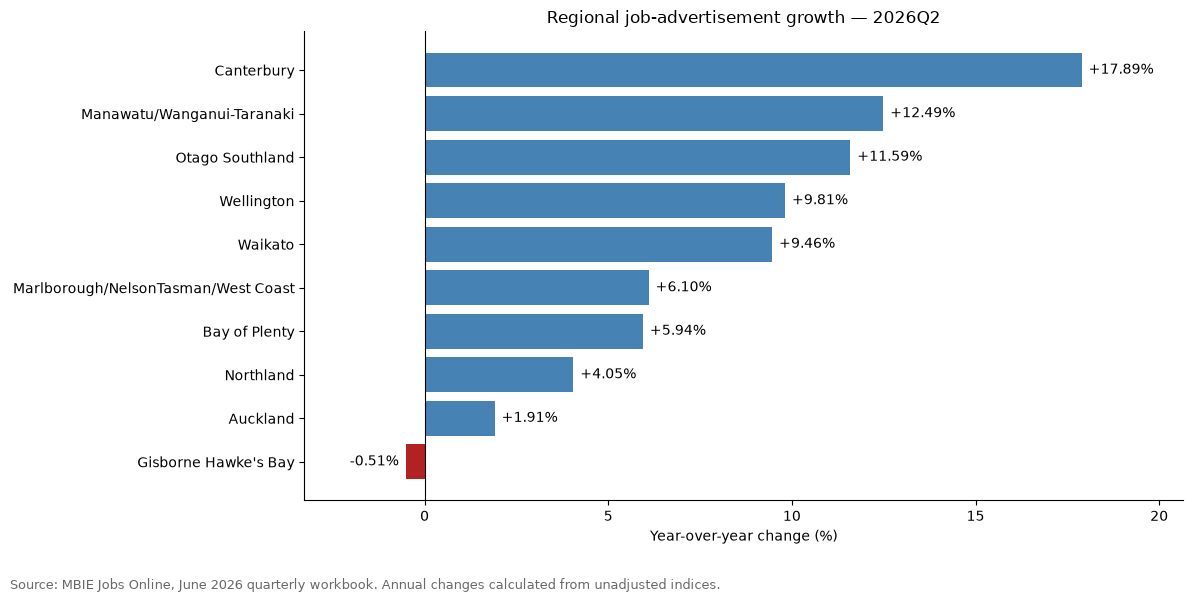

In [19]:
import matplotlib.pyplot as plt

growth_to_plot = latest_summary["yoy_change_pct"].sort_values()

colors = [
    "steelblue" if value >= 0 else "firebrick"
    for value in growth_to_plot
]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    growth_to_plot.index,
    growth_to_plot.values,
    color=colors
)

ax.bar_label(
    bars,
    labels=[f"{value:+.2f}%" for value in growth_to_plot],
    padding=5
)

ax.margins(x=0.15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    "Source: MBIE Jobs Online, June 2026 quarterly workbook. "
    "Annual changes calculated from unadjusted indices.",
    fontsize=9,
    color="dimgray"
)

latest_quarter = regional_indices.index[-1].to_period("Q")

ax.set_title(f"Regional job-advertisement growth — {latest_quarter}")
ax.set_xlabel("Year-over-year change (%)")
ax.set_ylabel("")
ax.axvline(0, color="black", linewidth=0.8)

fig.tight_layout(rect=[0, 0.06, 1, 1])

figure_path = Path("../reports/figures/regional_yoy_growth_2026Q2.png")

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()